# Deep Learning Mid-Term Break Assignment



*   Student Name: Chai Jie Sheng
*   Matriks Number: 22100945/1
* Lecturer: Profesor Madya Ts. Dr. Aznul Qalib bin Md Sabri



## 1. Setup & Imports

In [6]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Dataset Preparation through Crawling and Saved in Local Machine


In [7]:
# Install & Imports
!pip install icrawler -q

import os, random, shutil, time, warnings, hashlib
warnings.filterwarnings("ignore")

from pathlib import Path
from PIL import Image, UnidentifiedImageError

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

from icrawler.builtin import BingImageCrawler, GoogleImageCrawler

# Mount Google Drive so images persist across sessions


CLASSES_QUERIES = {
    'cendol':         ['cendol Malaysian dessert', 'cendol bowl',
                       'cendol green noodles dessert', 'ais cendol'],
    'char_kuey_teow': ['char kuey teow Malaysia', 'char kway teow stir fry',
                       'penang char kuey teow'],
    'nasi_lemak':     ['nasi lemak Malaysia', 'nasi lemak coconut rice', 'nasi lemak dish'],
    'roti_canai':     ['roti canai Malaysia', 'roti canai flatbread', 'roti canai mamak'],
    'satay':          ['satay Malaysia', 'satay grilled skewer', 'malaysian satay chicken'],
}
CLASSES   = list(CLASSES_QUERIES.keys())
DATA_ROOT = Path('C:/Users/USER/Documents/Personal File/Deep Learning/malaysian_food')
RAW_DIR   = DATA_ROOT / 'raw'
SPLIT_DIR = DATA_ROOT / 'split'
TARGET    = 200   # crawl target per class (allows buffer after manual cleaning)
SEED      = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# Run once to clear old split 
import shutil
if SPLIT_DIR.exists():
    shutil.rmtree(str(SPLIT_DIR))
    print("✅ Old split deleted")

### 2.1 Image Crawling
Crawl images from Bing and Google Image Search using multiple search queries per class to maximise diversity. Target classes:
- `cendol`
- `char_kuey_teow`
- `nasi_lemak`
- `roti_canai`
- `satay`

In [ ]:
# Crawl images (multi-query Bing + Google fallback)
def crawl_class(cls, queries, target=TARGET):
    save_dir = RAW_DIR / cls
    save_dir.mkdir(parents=True, exist_ok=True)

    existing = len(list(save_dir.glob('*')))
    if existing >= target:
        print(f"  [{cls}] {existing} images already exist — skipping")
        return

    per_q = max(target // len(queries) + 20, 60)
    print(f"  [{cls}] crawling ~{per_q} per query across {len(queries)} queries …")

    for i, query in enumerate(queries):
        tmp = Path(f'_tmp_{cls}_{i}')
        tmp.mkdir(exist_ok=True)
        try:
            c = BingImageCrawler(
                storage={'root_dir': str(tmp)},
                feeder_threads=2, parser_threads=2, downloader_threads=6,
            )
            c.crawl(keyword=query, max_num=per_q,
                    filters={'type': 'photo', 'size': 'medium'})
        except Exception as e:
            print(f'    Bing failed ({e}), trying Google…')
            try:
                c = GoogleImageCrawler(
                    storage={'root_dir': str(tmp)},
                    feeder_threads=1, parser_threads=1, downloader_threads=4,
                )
                c.crawl(keyword=query, max_num=per_q)
            except Exception as e2:
                print(f'    Google also failed: {e2}')

        for p in tmp.glob('*'):
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.webp', '.gif'}:
                shutil.move(str(p), str(save_dir / f'{cls}_q{i}_{p.name}'))
        shutil.rmtree(str(tmp), ignore_errors=True)
        time.sleep(1)

    n = len(list(save_dir.glob('*')))
    print(f"  [{cls}] → {n} images total")

print("=== Crawling ===")
for cls, queries in CLASSES_QUERIES.items():
    crawl_class(cls, queries)

### 2.2 Auto-Cleaning
Automatically remove corrupt, duplicate, and undersized images using PIL verification and MD5 hashing.

In [ ]:
# Auto-clean (corrupt / duplicates / tiny images)
def validate_and_clean(raw_root, min_px=64):
    print("=== Auto-cleaning ===")
    for cls_dir in sorted(raw_root.iterdir()):
        if not cls_dir.is_dir(): continue
        kept, removed, seen = 0, 0, set()
        for p in list(cls_dir.glob('*')):
            try:
                with Image.open(p) as im: im.verify()
                with Image.open(p) as im:
                    if min(im.size) < min_px:
                        raise ValueError('too small')
                    h = hashlib.md5(p.read_bytes()).hexdigest()
                    if h in seen:
                        raise ValueError('duplicate')
                    seen.add(h)
                    rgb  = im.convert('RGB')
                    new  = p.with_suffix('.jpg')
                    if new != p: p.unlink()
                    rgb.save(str(new), 'JPEG', quality=90)
                    kept += 1
            except Exception:
                p.unlink(missing_ok=True); removed += 1
        status = '✅' if kept >= 150 else '⚠️  BELOW 150 — crawl more or add images manually'
        print(f"  {status}  {cls_dir.name}: kept={kept}, removed={removed}")

validate_and_clean(RAW_DIR)

print("\n" + "="*60)
print("👉 NOW manually delete any wrong/bad images in Google Drive:")
print("   drive.google.com → malaysian_food/raw/<class>/")
print("   Then run Cell 4 onwards.")
print("="*60)

In [ ]:
# Balance classes by capping to same count
CLASSES = ['cendol', 'char_kuey_teow', 'nasi_lemak', 'roti_canai', 'satay']

def balance_classes(raw_root, max_per_class=None):
    # Find the smallest class count
    counts = {}
    for cls_dir in sorted(raw_root.iterdir()):
        if not cls_dir.is_dir(): continue
        counts[cls_dir.name] = len(list(cls_dir.glob('*.jpg')))

    cap = max_per_class or min(counts.values())
    print(f"=== Balancing all classes to {cap} images ===")

    for cls_dir in sorted(raw_root.iterdir()):
        if not cls_dir.is_dir(): continue
        files = list(cls_dir.glob('*.jpg'))
        random.shuffle(files)
        # Delete excess images
        for p in files[cap:]:
            p.unlink()
        final = len(list(cls_dir.glob('*.jpg')))
        print(f"  {cls_dir.name}: {final} images")

balance_classes(RAW_DIR)  # auto caps to smallest class

### 2.3 Manual Cleaning in Local Machine

In [8]:
# Check counts after manual cleaning
print("=== Final image counts (after manual cleaning) ===")
for cls in CLASSES:
    d = RAW_DIR / cls
    n = len(list(d.glob('*.jpg')))
    flag = '✅' if n >= 100 else '⚠️  LOW'
    print(f"  {flag}  {cls}: {n} images")

=== Final image counts (after manual cleaning) ===
  ✅  cendol: 157 images
  ✅  char_kuey_teow: 157 images
  ✅  nasi_lemak: 157 images
  ✅  roti_canai: 157 images
  ✅  satay: 157 images


## 3. Data Splitting & Balancing


### 3.1 Train / Val / Test Split
Split the balanced dataset into:
| Split | Ratio | Purpose |
|-------|-------|---------|
| Train | 70%   | Model training |
| Val   | 15%   | Hyperparameter tuning |
| Test  | 15%   | Final evaluation |

In [ ]:
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15

for split in ("train", "val", "test"):
    for cls in CLASSES:
        (SPLIT_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def split_class(label):
    src   = RAW_DIR / label
    files = list(src.glob('*.jpg'))
    random.shuffle(files)
    n       = len(files)
    n_train = int(n * TRAIN_SPLIT)
    n_val   = int(n * VAL_SPLIT)
    splits  = {
        'train': files[:n_train],
        'val'  : files[n_train : n_train + n_val],
        'test' : files[n_train + n_val:],
    }
    for split, flist in splits.items():
        for p in flist:
            dst = SPLIT_DIR / split / label / p.name
            if not dst.exists():
                shutil.copy(str(p), str(dst))
    print(f"  [{label}] train={len(splits['train'])} | val={len(splits['val'])} | test={len(splits['test'])}")

print("=== Splitting ===")
for cls in CLASSES:
    split_class(cls)

=== Splitting ===
  [cendol] train=109 | val=23 | test=25
  [char_kuey_teow] train=109 | val=23 | test=25
  [nasi_lemak] train=109 | val=23 | test=25
  [roti_canai] train=109 | val=23 | test=25
  [satay] train=109 | val=23 | test=25


Checking: C:\Users\USER\Documents\Personal File\Deep Learning\malaysian_food\raw\cendol
Exists: True
Found 157 images


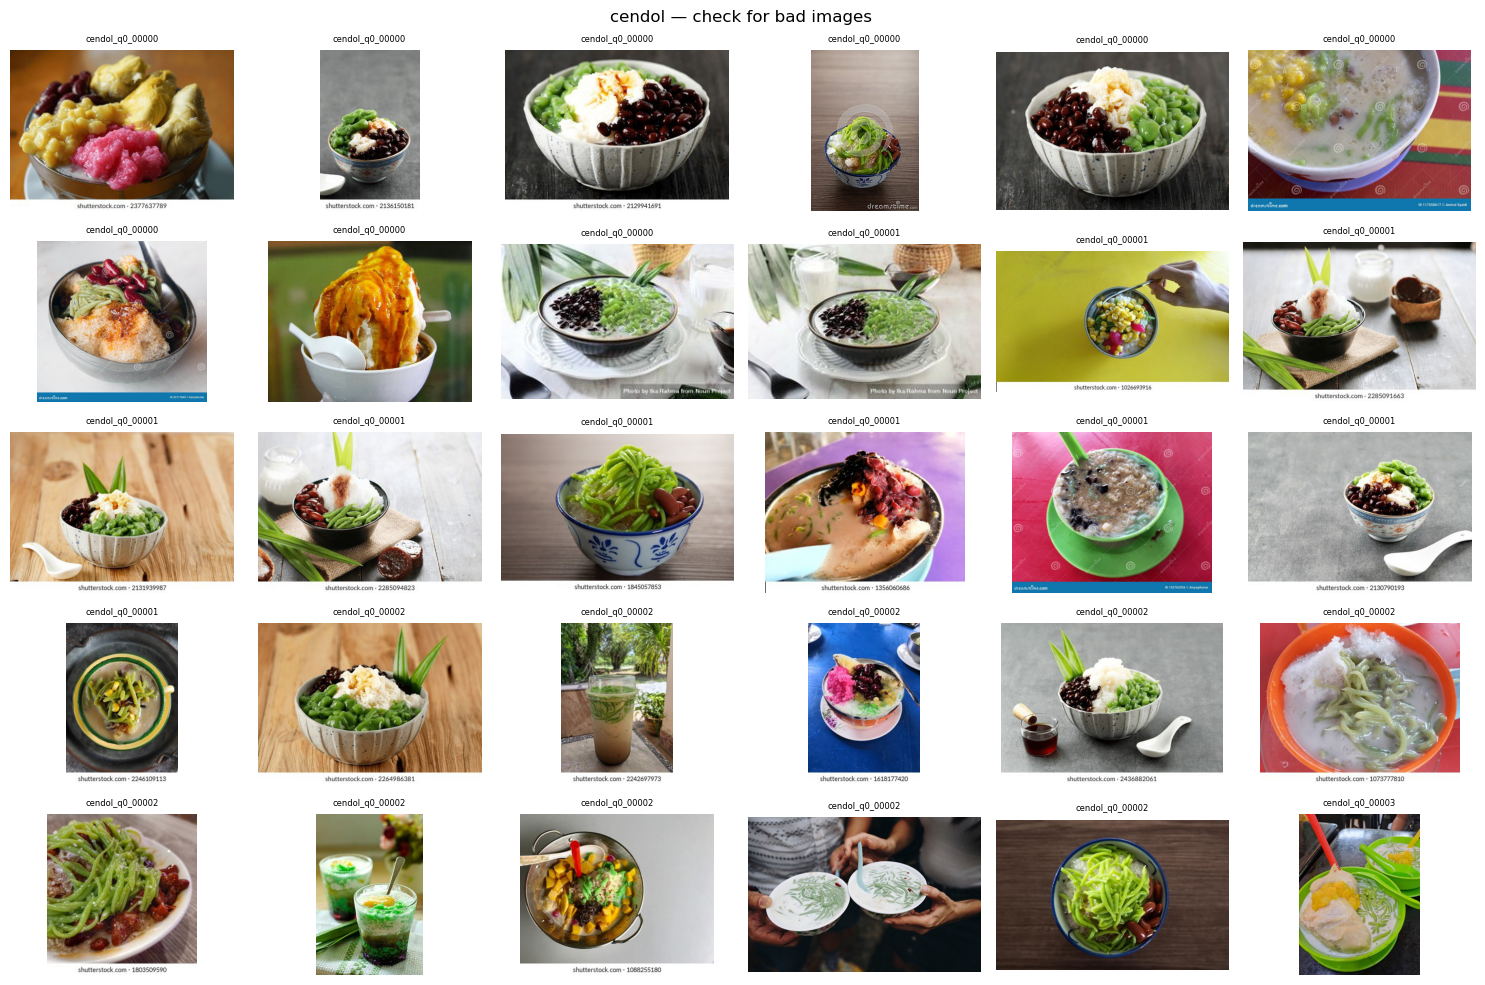

In [26]:
CLASS_TO_CHECK = 'cendol'

img_dir = DATA_ROOT / 'raw' / CLASS_TO_CHECK

print(f"Checking: {img_dir}")
print(f"Exists: {img_dir.exists()}")

imgs = list(img_dir.glob('*'))

print(f"Found {len(imgs)} images")

fig, axes = plt.subplots(5, 6, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i >= len(imgs):
        ax.axis('off')
        continue

    ax.imshow(Image.open(imgs[i]))
    ax.set_title(imgs[i].name[:15], fontsize=6)
    ax.axis('off')

plt.suptitle(f'{CLASS_TO_CHECK} — check for bad images')
plt.tight_layout()
plt.show()

In [ ]:
# Run this ONCE to fully wipe split folder
import shutil
if SPLIT_DIR.exists():
    shutil.rmtree(str(SPLIT_DIR))
    print(f"✅ Deleted: {SPLIT_DIR}")
else:
    print("⚠️ Not found — check SPLIT_DIR path")
    print(f"   Looking at: {SPLIT_DIR}")

✅ Deleted: /content/drive/MyDrive/malaysian_food/split



## 4. Data Loaders & Augmentation <a id="loaders"></a>

Build PyTorch DataLoaders with the following augmentation pipeline for training:

| Augmentation | Purpose |
|---|---|
| Random Crop | Positional invariance |
| Horizontal Flip | Mirror invariance |
| Color Jitter | Lighting variation |
| Random Rotation | Orientation invariance |
| Normalize (ImageNet) | Stable gradient flow |

In [12]:
# Load Data into DataLoaders
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

IMG_SIZE = 224
BATCH    = 32
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'

train_tfm = T.Compose([
    T.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    T.RandomCrop(IMG_SIZE),                        # ✅ added
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(str(SPLIT_DIR / 'train'), transform=train_tfm)
val_ds   = ImageFolder(str(SPLIT_DIR / 'val'),   transform=val_test_tfm)
test_ds  = ImageFolder(str(SPLIT_DIR / 'test'),  transform=val_test_tfm)
CLASS_NAMES = train_ds.classes

print(f'Classes    : {CLASS_NAMES}')
print(f'Train size : {len(train_ds)}')
print(f'Val size   : {len(val_ds)}')
print(f'Test size  : {len(test_ds)}')

# WeightedRandomSampler
label_counts   = Counter(train_ds.targets)
class_weights  = {c: 1.0/n for c, n in label_counts.items()}
sample_weights = [class_weights[l] for l in train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

Classes    : ['cendol', 'char_kuey_teow', 'nasi_lemak', 'roti_canai', 'satay']
Train size : 545
Val size   : 115
Test size  : 125


## 5. Custom CNN Architecture

### 5.1 Model Architecture

In [13]:
class MalaysiaFoodCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.block_1 = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.block_2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.block_3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2))
        self.block_4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2))
        self.gap = nn.AdaptiveAvgPool2d(1)  # ← fixes the size issue
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.gap(x)
        return self.classifier(x)

In [14]:
torch.manual_seed(42)
model = MalaysiaFoodCNN(num_classes=5)
model


MalaysiaFoodCNN(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [80]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model)
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")

Total params: 456,453
Trainable params: 456,453


In [33]:
# function of train_step & test_step
from tqdm.auto import tqdm

def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device=DEVICE):
    train_loss, train_acc = 0, 0
    model.train()
    model.to(device)
    for X, y in tqdm(data_loader, desc="Training", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc  += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    train_loss /= len(data_loader)
    train_acc  /= len(data_loader)
    return train_loss, train_acc

def test_step(data_loader, model, loss_fn, accuracy_fn, device=DEVICE):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader, desc="Validating", leave=False):
            X, y = X.to(device), y.to(device)
            test_pred  = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc  += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(data_loader)
        test_acc  /= len(data_loader)
    return test_loss, test_acc

In [36]:
# CELL — Accuracy function
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


### Parameter Count

The proposed custom CNN contains a total of **456,453 parameters**, all of which are trainable.

| Type | Number of Parameters |
|------|---------------------|
| Total Parameters | 456,453 |
| Trainable Parameters | 456,453 |
| Non-trainable Parameters | 0 |

### Layer Shapes Analysis

The input image of size **(3, 224, 224)** is progressively transformed through convolutional blocks, where spatial dimensions decrease while feature depth increases.

| Block | Operation | Output Shape |
|------|----------|-------------|
| Input | Image | (3, 224, 224) |
| Block 1 | Conv → BN → ReLU → MaxPool | (32, 112, 112) |
| Block 2 | Conv → BN → ReLU → MaxPool | (64, 56, 56) |
| Block 3 | Conv → BN → ReLU → MaxPool | (128, 28, 28) |
| Block 4 | Conv → BN → ReLU → MaxPool | (256, 14, 14) |
| GAP | AdaptiveAvgPool | (256, 1, 1) |
| Flatten | — | (256) |
| Classifier | Fully Connected | (5) |



### Receptive Field Analysis

The receptive field describes how much of the input image each neuron can observe. It increases with depth, allowing deeper layers to capture broader contextual information.

| Layer | Operation | Kernel / Stride | Receptive Field |
|------|----------|----------------|----------------|
| Conv1 | 3×3 conv | k=3, s=1 | 3 |
| Pool1 | 2×2 maxpool | k=2, s=2 | 6 |
| Conv2 | 3×3 conv | k=3, s=1 | 10 |
| Pool2 | 2×2 maxpool | k=2, s=2 | 20 |
| Conv3 | 3×3 conv | k=3, s=1 | 28 |
| Pool3 | 2×2 maxpool | k=2, s=2 | 56 |
| Conv4 | 3×3 conv | k=3, s=1 | 72 |
| Pool4 | 2×2 maxpool | k=2, s=2 | 144 |

The receptive field increases progressively across convolutional layers, reaching around **144×144 pixels** at the ennd. This allows the network to capture both local texture details and global structural patterns of the food images. A larger receptive field is particularly important for distinguishing visually similar dishes, as it allows the model to consider the overall structure and context of the image rather than focusing only on small regions.


### 5.2 Training Configuration

# Prepare model for MalaysiaFoodCNN
import torch
torch.manual_seed(42)

EPOCHS = 30

# Reset model
model = MalaysiaFoodCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)

# Reset criterion with class weights
from collections import Counter
from torch.optim.lr_scheduler import CosineAnnealingLR

label_counts = Counter(train_ds.targets)
freq      = torch.tensor([label_counts[i] for i in range(len(CLASS_NAMES))], dtype=torch.float)
w         = (1.0/freq); w = (w/w.sum()*len(CLASS_NAMES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=w)

# Reset optimizer and scheduler pointing to NEW model
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

# Reset histories
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("✅ Model, optimizer, scheduler all reset — ready to train")

### 5.3 Training Loop

In [56]:
# CELL — Single training loop  
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
CKPT_PATH    = 'best_model.pth'
foodcnn_start = time.time()
for epoch in range(1, EPOCHS + 1):
    tl, ta = train_step(model, train_loader, criterion, optimizer, accuracy_fn, DEVICE)
    vl, va = test_step(val_loader, model, criterion, accuracy_fn, DEVICE)
    scheduler.step()

    history['train_loss'].append(tl)
    history['train_acc'].append(ta)
    history['val_loss'].append(vl)
    history['val_acc'].append(va)

    print(f"Epoch {epoch:>3}/{EPOCHS} | "
          f"Train loss: {tl:.5f} | Train acc: {ta:.2f}% | "
          f"Val loss: {vl:.5f} | Val acc: {va:.2f}%", end="")

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), CKPT_PATH)
        print("  ★ saved", end="")
    print()

foodcnn_total_time = time.time() - foodcnn_start
print(f'\nDone. Best val acc: {best_val_acc:.2f}%')
print(f'Total time: {foodcnn_total_time/60:.1f} mins')

Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch   1/30 | Train loss: 1.55404 | Train acc: 30.73% | Val loss: 1.55738 | Val acc: 28.66%  ★ saved


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  29/30 | Train loss: 1.03807 | Train acc: 58.68% | Val loss: 1.04757 | Val acc: 55.88%


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  30/30 | Train loss: 1.03028 | Train acc: 63.72% | Val loss: 0.99238 | Val acc: 60.03%

Done. Best val acc: 64.47%
Total time: 3.2 mins


## 6. Transfer Learning — ResNet-50

In [57]:
#import necessary libraries
import torch as nn
from torchvision import models
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import warnings
import torch.nn as nn
import time
warnings.filterwarnings('ignore')
%matplotlib inline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Using {device} for inference')

Using cuda for inference


In [40]:
# CELL 18 — Load ResNet50
import torchvision.models as models

resnetModel = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze resnetModel backbone (NOT model/CNN)
for param in resnetModel.parameters():       # ← was: model.parameters()
    param.requires_grad = False

resnetModel.fc = nn.Sequential(
    nn.Linear(resnetModel.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(CLASS_NAMES))
)

resnetModel = resnetModel.to(DEVICE)         # ← was: model = model.to(DEVICE)
print(f"   CNN model intact: {type(resnetModel).__name__}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 23.2MB/s]


   CNN model intact: ResNet


### 6.1 Train Head First (5 epochs)

In [41]:
EPOCHS_1 = 5
EPOCHS_2 = 25
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay = 1e-4

)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)
history_resnet = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_r     = 0.0
resnetStart_time     = time.time()

print("=== Phase 1: Head only ===")
for epoch in range(1, EPOCHS_1 + 1):
    tl, ta = train_step(resnetModel, train_loader, criterion, optimizer, accuracy_fn, DEVICE)
    vl, va = test_step(val_loader, resnetModel, criterion, accuracy_fn, DEVICE)
    scheduler.step(vl)
    history_resnet['train_loss'].append(tl)
    history_resnet['train_acc'].append(ta)
    history_resnet['val_loss'].append(vl)
    history_resnet['val_acc'].append(va)

    if va > best_val_r:
        best_val_r = va
        torch.save(resnetModel.state_dict(), 'best_resnet.pth')
        print(f"Epoch {epoch}/{EPOCHS_1} | Train: {ta:.2f}% | Val: {va:.2f}%  ★")
    else:
        print(f"Epoch {epoch}/{EPOCHS_1} | Train: {ta:.2f}% | Val: {va:.2f}%")


=== Phase 1: Head only ===


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 | Train: 21.01% | Val: 22.45%  ★


Training:   0%|          | 0/18 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 | Train: 28.12% | Val: 24.01%  ★


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 | Train: 18.40% | Val: 23.23%


### 6.2 Phase 2 — Full Fine-Tuning (25 epochs)
Unfreeze layer 4 and fine-tune the full network using differential learning

In [42]:
# Unfreeze layer4
for param in resnetModel.layer4.parameters():
    param.requires_grad = True

optimizer_r2 = torch.optim.Adam([
    {'params': resnetModel.layer4.parameters(), 'lr': 1e-5},
    {'params': resnetModel.fc.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)

In [43]:
# Fine-tuning the layer 4 and fc layers
print("=== Phase 2: Fine-tuning ===")
for epoch in range(1, EPOCHS_2 + 1):
    tl, ta = train_step(resnetModel, train_loader, criterion, optimizer_r2, accuracy_fn, DEVICE)
    vl, va = test_step(val_loader, resnetModel, criterion, accuracy_fn, DEVICE)
    scheduler.step(vl)
    history_resnet['train_loss'].append(tl)
    history_resnet['train_acc'].append(ta)
    history_resnet['val_loss'].append(vl)
    history_resnet['val_acc'].append(va)

    if va > best_val_r:
        best_val_r = va
        torch.save(resnetModel.state_dict(), 'best_resnet.pth')
        print(f"Epoch {epoch}/{EPOCHS_2} | Train: {ta:.2f}% | Val: {va:.2f}%  ★")
    else:
        print(f"Epoch {epoch}/{EPOCHS_2} | Train: {ta:.2f}% | Val: {va:.2f}%")

total_time_r = time.time() - resnetStart_time
print(f"\nBest Val Acc : {best_val_r:.2f}%")
print(f"Total Time   : {total_time_r/60:.1f} mins")

=== Phase 2: Fine-tuning ===


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/25 | Train: 34.38% | Val: 51.11%  ★


Training:   0%|          | 0/18 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 24/25 | Train: 97.05% | Val: 86.97%


Training:   0%|          | 0/18 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 25/25 | Train: 91.32% | Val: 88.28%

Best Val Acc : 89.84%
Total Time   : 3.7 mins


## 7. Comparison and Analysis 
### 7.1 Confusion Matrix Analysis

                precision    recall  f1-score   support

        cendol       0.75      0.72      0.73        25
char_kuey_teow       0.37      0.64      0.47        25
    nasi_lemak       0.67      0.48      0.56        25
    roti_canai       0.76      0.64      0.70        25
         satay       0.32      0.24      0.27        25

      accuracy                           0.54       125
     macro avg       0.57      0.54      0.55       125
  weighted avg       0.57      0.54      0.55       125



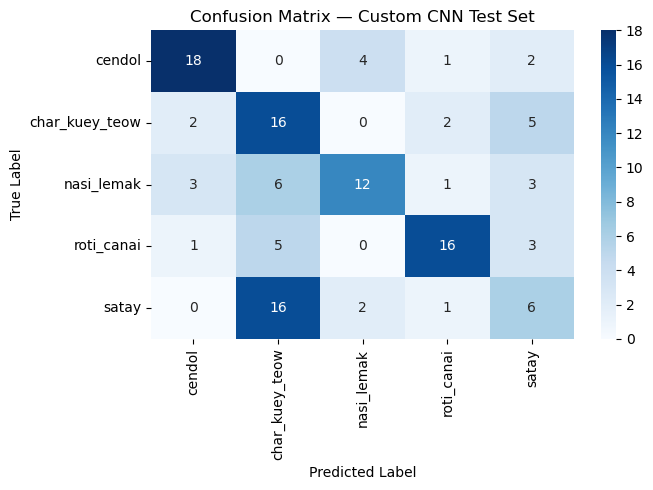

In [69]:
# Visualise through confusion Matrix of Resnet50 model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.inference_mode():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds = model(X).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# Classification report
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Custom CNN Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_customcnn.png', dpi=150)
plt.show()

                precision    recall  f1-score   support

        cendol       0.89      1.00      0.94        25
char_kuey_teow       0.88      0.88      0.88        25
    nasi_lemak       0.96      0.96      0.96        25
    roti_canai       0.96      0.88      0.92        25
         satay       0.96      0.92      0.94        25

      accuracy                           0.93       125
     macro avg       0.93      0.93      0.93       125
  weighted avg       0.93      0.93      0.93       125



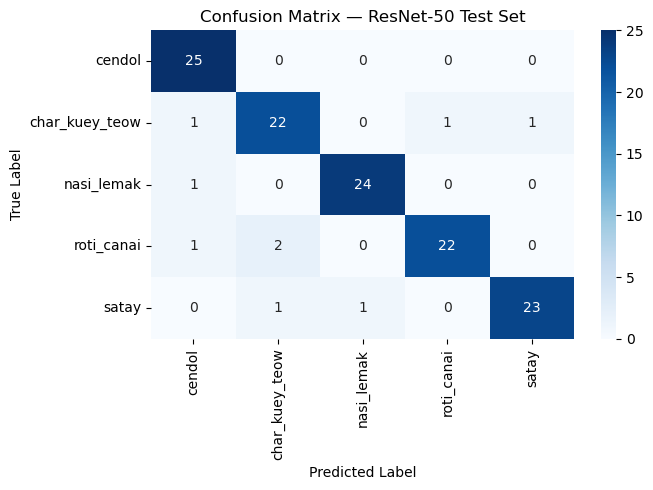

In [44]:
# Visualise through confusion Matrix of Resnet50 model

resnetModel.load_state_dict(torch.load('best_resnet.pth', map_location=DEVICE))
resnetModel.eval()

all_preds, all_labels = [], []
with torch.inference_mode():
    for X, y in test_loader:
        X = X.to(DEVICE)
        preds = resnetModel(X).argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

# Classification report
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — ResNet-50 Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_resnet.png', dpi=150)
plt.show()

In [45]:
import random

def show_predictions(model, dataset, class_names, n=20, title='Sample Predictions'):
    model.eval()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    # ✅ define indices BEFORE loop
    indices = random.sample(range(len(dataset)), n)

    for i, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]

        with torch.inference_mode():
            logits = model(img_tensor.unsqueeze(0).to(DEVICE))
            probs = torch.softmax(logits, dim=1)

            pred_label = probs.argmax(dim=1).item()
            confidence = probs.max().item()

        # ✅ move inside loop
        img = img_tensor.permute(1, 2, 0).numpy()
        img = np.clip(img * std + mean, 0, 1)

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        correct = pred_label == true_label
        color = 'green' if correct else 'red'

        ax.set_title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Conf: {confidence:.0%}",
            fontsize=8,
            color=color
        )

    # Hide extra axes
    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

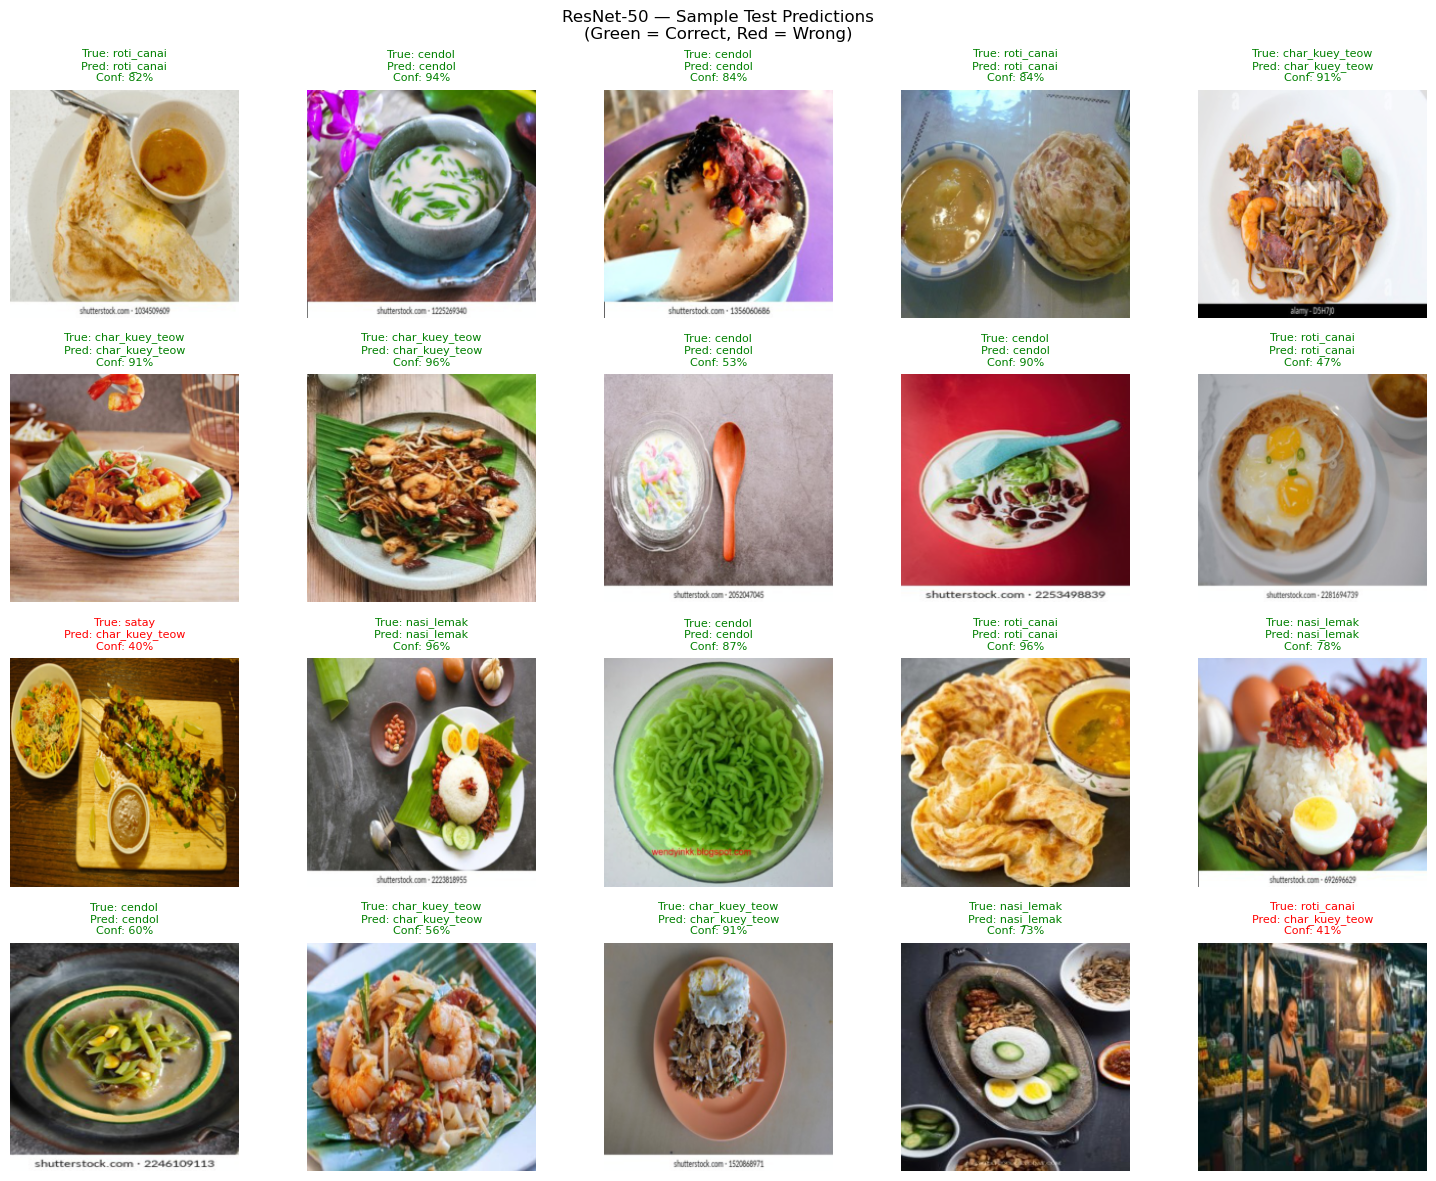

In [46]:
show_predictions(resnetModel, test_ds, CLASS_NAMES, n=20,
                 title='ResNet-50 — Sample Test Predictions\n(Green = Correct, Red = Wrong)')


### 7.2 Model Comparison using Learning Curve

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Validating:   0%|          | 0/4 [00:00<?, ?it/s]

Metric                           Custom CNN    ResNet-50
Best Val Acc                         63.94%       89.84%
Test Acc                             59.32%       92.73%
Total Epochs                             30           30
Converge to 60% (epoch)                  22            7
Total Train Time                      3.3m        3.7m
Pretrained Weights                       No          Yes


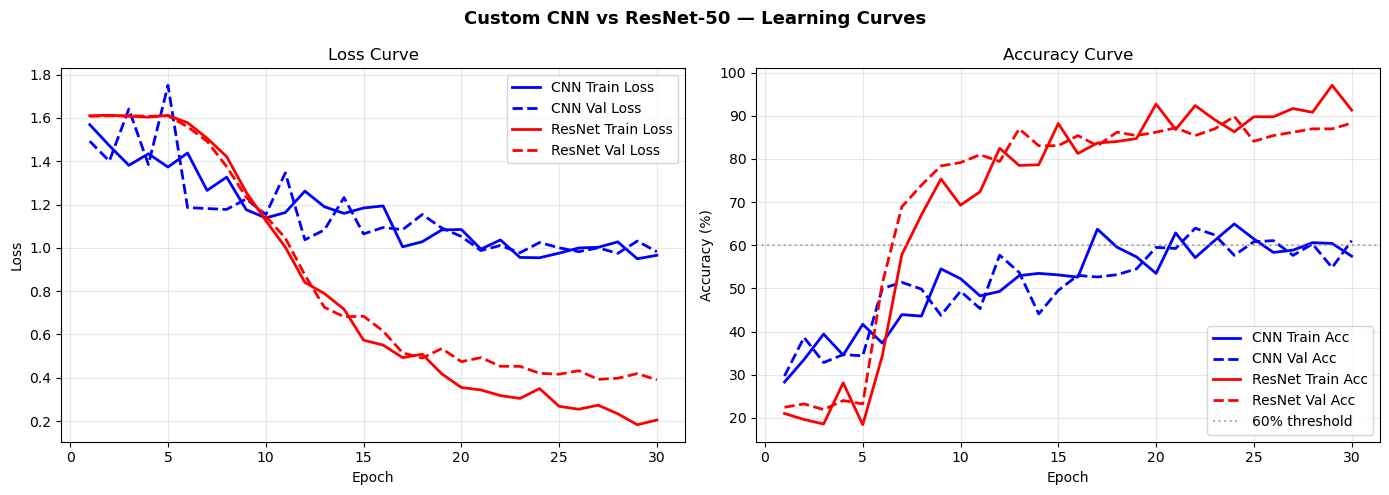

In [47]:
# Comparison with Accuracy, Time, Convergence and Learning Curves

# ── 1. Test both models ──
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
resnetModel.load_state_dict(torch.load('best_resnet.pth', map_location=DEVICE))

_, cnn_test_acc    = test_step(test_loader, model,      criterion,   accuracy_fn, DEVICE)
_, resnet_test_acc = test_step(test_loader, resnetModel, criterion,  accuracy_fn, DEVICE)

# ── 2. Convergence speed (first epoch val acc >= 60%) ──
def convergence_epoch(val_accs, threshold=60.0):
    for i, acc in enumerate(val_accs):
        if acc >= threshold:
            return i + 1
    return None

cnn_conv    = convergence_epoch(history['val_acc'])
resnet_conv = convergence_epoch(history_resnet['val_acc'])

# ── 3. Comparison Table ──
print("=" * 58)
print(f"{'Metric':<30} {'Custom CNN':>12} {'ResNet-50':>12}")
print("=" * 58)
print(f"{'Best Val Acc':<30} {max(history['val_acc']):>11.2f}% {best_val_r:>11.2f}%")
print(f"{'Test Acc':<30} {cnn_test_acc:>11.2f}% {resnet_test_acc:>11.2f}%")
print(f"{'Total Epochs':<30} {len(history['val_acc']):>12} {len(history_resnet['val_acc']):>12}")
print(f"{'Converge to 60% (epoch)':<30} {str(cnn_conv) if cnn_conv else 'Never':>12} {str(resnet_conv) if resnet_conv else 'Never':>12}")
print(f"{'Total Train Time':<30} {foodcnn_total_time/60:>10.1f}m {total_time_r/60:>10.1f}m")
print(f"{'Pretrained Weights':<30} {'No':>12} {'Yes':>12}")
print("=" * 58)

# ── 4. Learning Curves ──
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN vs ResNet-50 — Learning Curves',
             fontsize=13, fontweight='bold')

cnn_ep    = range(1, len(history['val_acc']) + 1)
resnet_ep = range(1, len(history_resnet['val_acc']) + 1)

# Loss
ax1.plot(cnn_ep,    history['train_loss'],        'b-',  linewidth=2, label='CNN Train Loss')
ax1.plot(cnn_ep,    history['val_loss'],          'b--', linewidth=2, label='CNN Val Loss')
ax1.plot(resnet_ep, history_resnet['train_loss'], 'r-',  linewidth=2, label='ResNet Train Loss')
ax1.plot(resnet_ep, history_resnet['val_loss'],   'r--', linewidth=2, label='ResNet Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(cnn_ep,    history['train_acc'],        'b-',  linewidth=2, label='CNN Train Acc')
ax2.plot(cnn_ep,    history['val_acc'],          'b--', linewidth=2, label='CNN Val Acc')
ax2.plot(resnet_ep, history_resnet['train_acc'], 'r-',  linewidth=2, label='ResNet Train Acc')
ax2.plot(resnet_ep, history_resnet['val_acc'],   'r--', linewidth=2, label='ResNet Val Acc')
ax2.axhline(y=60, color='gray', linestyle=':', alpha=0.6, label='60% threshold')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print(f"CNN epochs       : {len(history['val_acc'])}")
print(f"ResNet epochs    : {len(history_resnet['val_acc'])}")
print(f"CNN train time   : {foodcnn_total_time/60:.1f} mins")
print(f"ResNet train time: {total_time_r/60:.1f} mins")
print(f"CNN test acc     : {cnn_test_acc:.2f}%")
print(f"ResNet test acc  : {resnet_test_acc:.2f}%")

CNN epochs       : 30
ResNet epochs    : 30
CNN train time   : 3.3 mins
ResNet train time: 3.7 mins
CNN test acc     : 59.32%
ResNet test acc  : 92.73%


In [54]:
# Instead of

MODEL_DIR = Path('C:/Users/USER/Documents/Personal File/Deep Learning/models')
MODEL_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), MODEL_DIR/ 'best_cnn.pth')
torch.save(resnetModel.state_dict(), MODEL_DIR/ 'best_resnet.pth')

# Same for loading
model.load_state_dict(torch.load(str(MODEL_DIR / 'best_cnn.pth'), map_location=DEVICE))
resnetModel.load_state_dict(torch.load(str(MODEL_DIR / 'best_resnet.pth'), map_location=DEVICE))

<All keys matched successfully>

### 7.3 Misclassified Sample Visualisation

In [63]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np

def denormalize(img_tensor, mean, std):
    """Convert normalized tensor back to image"""
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)


def get_misclassified_samples(model, dataloader, class_names, device, max_samples=10):
    model.eval()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    misclassified = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            for i in range(images.size(0)):
                if preds[i] != labels[i]:
                    confidence = probs[i][preds[i]].item()

                    misclassified.append((
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].item(),
                        confidence
                    ))

                if len(misclassified) >= max_samples:
                    break

            if len(misclassified) >= max_samples:
                break

    # ---- Visualise ----
    cols = 5
    rows = (max_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()
    num_to_show = min(max_samples, len(misclassified))
    for i in range(num_to_show):
        img, true, pred, conf = misclassified[i]

        img = denormalize(img, mean, std)

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        color = 'red'

        ax.set_title(
            f"True: {class_names[true]}\n"
            f"Pred: {class_names[pred]}\n"
            f"Conf: {conf:.2%}",
            color=color,
            fontsize=9
        )

    # hide empty plots
    for j in range(max_samples, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Misclassified Samples Analysis", fontsize=14)
    plt.tight_layout()
    plt.show()

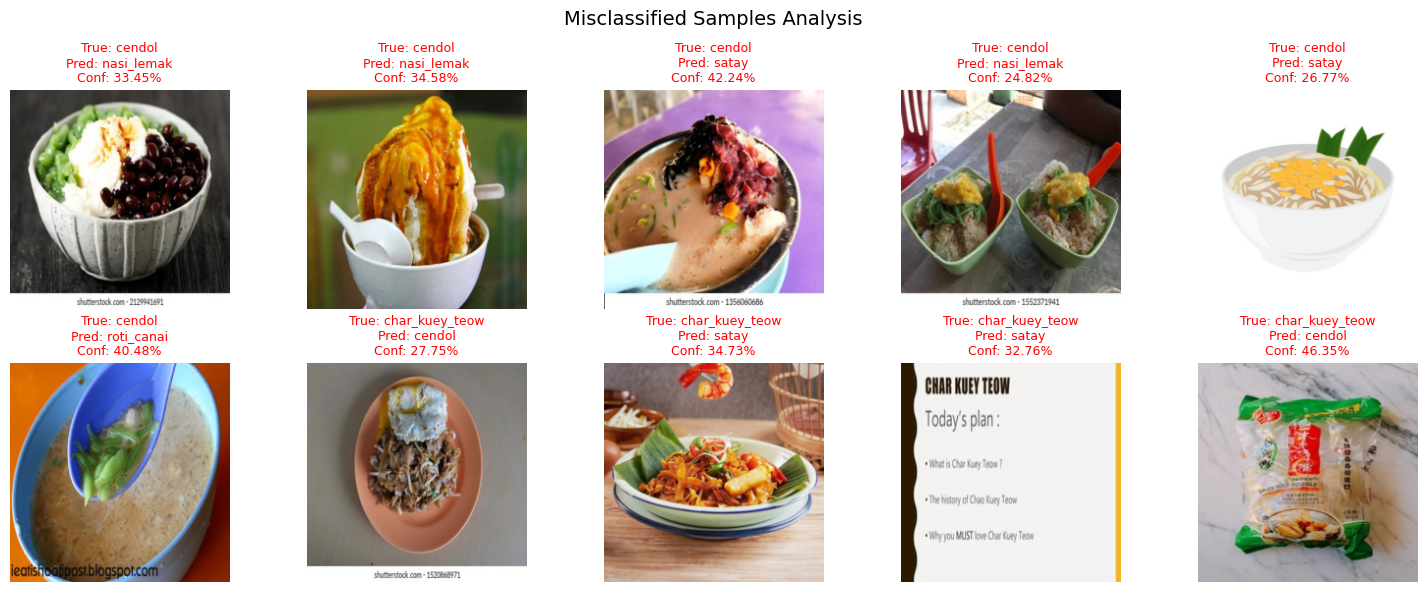

In [66]:
get_misclassified_samples(model, test_loader, CLASS_NAMES, DEVICE, max_samples=10)


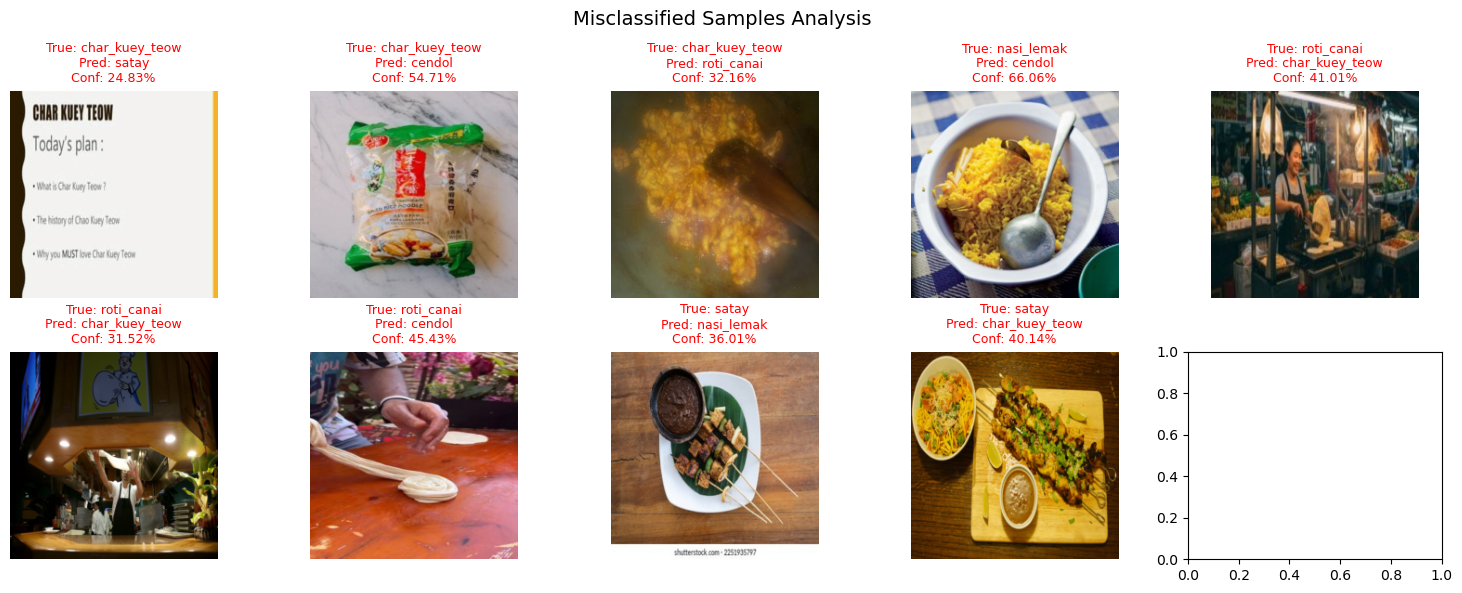

In [67]:
get_misclassified_samples(resnetModel, test_loader, CLASS_NAMES, DEVICE, max_samples=10)

### Overall Performance & Per-Class F1-Score

| Metric | Custom CNN | ResNet-50 |
|---|:---:|:---:|
| **Test Accuracy** | 59.32% | **92.73%** |
| **Best Val Accuracy** | 64.47% | **89.84%** |
| **Total Epochs** | 30 | 30 |
| **Converge to 60% (Epoch)** | 22 | **7** |
| **Total Train Time** | 3.3 min | 3.7 min |
| **Pretrained Weights** | ❌ | ✅ |
|  |  |  |
| **Cendol F1** | 0.73 | **0.94** |
| **Char Kuey Teow F1** | 0.47 | **0.88** |
| **Nasi Lemak F1** | 0.56 | **0.96** |
| **Roti Canai F1** | 0.70 | **0.92** |
| **Satay F1** | 0.27 | **0.94** |
| **Macro Avg F1** | 0.55 | **0.93** |

### Table 2 — Key Takeaways

| # | Observation | Finding |
|:---:|---|---|
| 1 | Best overall model | ResNet-50 (+33.41% test accuracy) |
| 2 | Hardest class for CNN | Satay (F1: 0.27) |
| 3 | Hardest class for ResNet | Char Kuey Teow (F1: 0.88) |
| 4 | Convergence speed | ResNet reached 60% **3× faster** (epoch 7 vs 22) |
| 5 | Training time difference | Only 0.4 min slower for ResNet |
| 6 | Most improved class | Satay (+0.67 F1 score improvement) |
| 7 | Most consistent class | Nasi Lemak (ResNet F1: 0.96) |

> 💡 ResNet-50 significantly outperforms the Custom CNN across all classes while taking nearly the same training time, demonstrating the clear advantage of transfer learning on small datasets.

## 8. Business Application & Reflection 
### 8.1 Proposed Improvement

**Data Improvement**

One of the main limitations of this project lies in the dataset size and quality. Since the images were web-crawled, the dataset contains various forms of noise, including watermarks, incorrect food labels, and irrelevant content such as stall environments instead of the actual dishes. These inconsistencies have contributed to incorrect model predictions across multiple samples.

To address this issue, it is recommended to increase the dataset size to at least 1,000 images per class using structured and high-quality datasets sourced from reputable platforms. In addition, manual data cleaning should be performed to ensure that irrelevant or misleading images are removed, thereby improving overall dataset reliability.

Furthermore, we would also suggest the use of MixUp as this approach allows the model to learn from blended image pairs rather than individual samples, which can improve generalisation and reduce overfitting, particularly in fine-grained classification tasks.

### 8.2 Malaysian SME Business Application

**Business Application - Food Delivery Platform Onboarding**

In recent years, online food ordering platforms have become increasingly important in Malaysia, with services such as GrabFood and Foodpanda serving as essential channels for small and medium-sized enterprise (SME) hawker stalls to reach a wider customer base. As a result, efficient and scalable onboarding processes have become crucial for these platforms.

This proposed model offers a very practical solution by automatically categorising and identifying food images submitted by vendors during the onboarding process. It is also particularly useful for people who do not understand the exact name of their product in the Malaysia context, especially hawkers and owners who are foreigners working in Malaysia. By leveraging image classification, the system can assist in verifying and organising food listings more efficiently, significantly reducing the reliance on manual review.

Traditionally, the onboarding process requires human reviewers to manually check and validate submitted food images and descriptions, which can be time-consuming and resource-intensive. With the integration of this model, the verification process can be accelerated from several days to potentially just a few minutes, improving operational efficiency on the platform side.

Moreover, for companies such as GrabFood and Foodpanda, this automation can help reduce labour costs while maintaining consistent and structured quality control over vendor submissions. At the same time, it allows hawker stalls and SMEs to get onboarded more quickly, enabling them to start selling their products with minimal delay. Overall, this system contributes to a more efficient, scalable, and cost-effective onboarding workflow for food delivery platforms in the Malaysian SME ecosystem.